In [8]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.fftpack import fft, fftfreq
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from ipywidgets import interact, IntSlider, FloatSlider
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

In [27]:
# Step 1: Generate complex synthetic time series data
t = np.arange(0, 20, 0.1)  # Time points from 0 to 20 with step size of 0.1
y = (5 * np.sin(2 * np.pi * t / 5) +         # Sine wave with period 5
     3 * np.cos(2 * np.pi * t / 3) +         # Cosine wave with period 3
     2 * np.sin(2 * np.pi * t / 7) +         # Sine wave with period 7
     1.5 * np.cos(2 * np.pi * t / 1.5) +     # Cosine wave with period 1.5
     np.random.normal(0, 0.5, len(t)))       # Adding random noise

In [28]:
# Step 2: Define Fourier series function with variable frequency and n_terms
def fourier_series(t, *a, dominant_freq):
    ret = a[0]  # Constant term
    n_terms = (len(a) - 1) // 2
    for i in range(1, n_terms + 1):
        ret += a[2*i-1] * np.cos(2 * np.pi * i * dominant_freq * t) + a[2*i] * np.sin(2 * np.pi * i * dominant_freq * t)
    return ret

In [29]:
# Step 3: Fit Fourier series to the generated data with adjustable n_terms, dominant_freq, and amplitude
def fit_fourier_series(n_terms, dominant_freq, amplitude):
    # Initial guess and bounds for the coefficients
    initial_guess = np.random.rand(2 * n_terms + 1)
    
    # Define a lambda function to pass the dominant_freq to the curve_fit function
    fourier_func = lambda t, *a: fourier_series(t, *a, dominant_freq=dominant_freq)
    
    # Fit the Fourier series to the generated data
    popt, _ = curve_fit(fourier_func, t, y, p0=initial_guess)
    
    # Generate predictions for a larger time range
    t_future = np.arange(0, 25, 0.1)
    
    # Apply the amplitude scaling factor to the Fourier series
    y_pred = amplitude * fourier_series(t_future, *popt, dominant_freq=dominant_freq)
    
    # Calculate the mean squared error (MSE)
    y_pred_mse = amplitude * fourier_series(t, *popt, dominant_freq=dominant_freq)
    mse = mean_squared_error(y, y_pred_mse)
    print("MSE of fitted model on train set:", round(mse, 2))
    
    # Plot the original data and the fitted Fourier series
    plt.figure(figsize=(14, 8))
    plt.scatter(t, y, label='Original Data', color='blue', s=15)
    plt.plot(t_future, y_pred, label=f'Fourier Series (n_terms={n_terms}, freq={dominant_freq:.2f}, amp={amplitude})', color='red')
    plt.axvline(x=t[-1], linestyle='--', color='green', label='Prediction Start')
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f'Fitting Fourier Series (MSE: {mse:.4f})')
    plt.title('Fitting Fourier Series with Adjustable n_terms, Frequency, and Amplitude')
    plt.show()

In [32]:
# Step 4: Create interactive sliders for n_terms, dominant_freq, and amplitude
interact(fit_fourier_series,
         n_terms=IntSlider(min=1, max=20, step=1, value=5, description='n_terms'),
         dominant_freq=FloatSlider(min=0.1, max=3, step=0.1, value=1.0, description='dominant_freq'),
         amplitude=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='amplitude'))

interactive(children=(IntSlider(value=5, description='n_terms', max=20, min=1), FloatSlider(value=1.0, descrip…

<function __main__.fit_fourier_series(n_terms, dominant_freq, amplitude)>

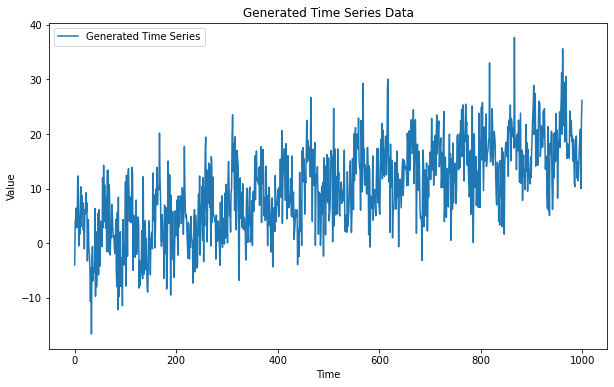

In [18]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Generate Time Series Data
def generate_time_series(n_points=1000):
    time = np.arange(0, n_points)
    trend = time * 0.02
    seasonality = 5 * np.sin(2 * np.pi * time / 50)
    noise = np.random.randn(n_points) * 5
    series = trend + seasonality + noise
    return time, series

time, series = generate_time_series()

# Plot the generated time series
plt.figure(figsize=(10, 6))
plt.plot(time, series, label='Generated Time Series')
plt.title("Generated Time Series Data")
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

Epoch 0/100, Loss: 0.018183
Epoch 10/100, Loss: 0.012664
Epoch 20/100, Loss: 0.012253
Epoch 30/100, Loss: 0.012099
Epoch 40/100, Loss: 0.012015
Epoch 50/100, Loss: 0.011977
Epoch 60/100, Loss: 0.011958
Epoch 70/100, Loss: 0.011943
Epoch 80/100, Loss: 0.011926
Epoch 90/100, Loss: 0.011907


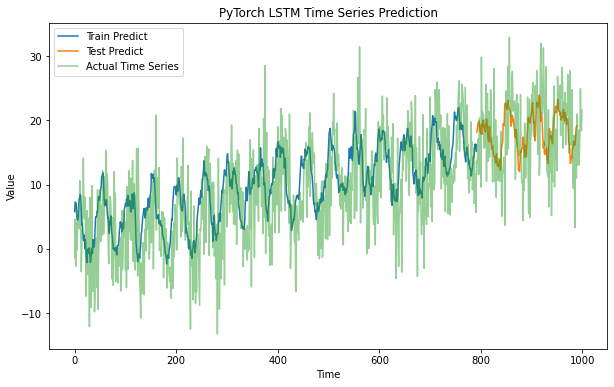

In [7]:
# Data Preparation
def create_dataset(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1))

# Set time_steps for supervised learning
time_steps = 10
X, y = create_dataset(series_scaled, time_steps)

# Convert to tensors
X = torch.Tensor(X)  # Shape: (samples, time_steps)
y = torch.Tensor(y)  # Shape: (samples, )

# Ensure correct shape (samples, time_steps, input_size)
X = X.view(X.shape[0], X.shape[1], 1)  # Now it is 3D: (samples, time_steps, 1)

# Split into training and testing data
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

# Define the LSTM Model using PyTorch
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super(LSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        predictions = self.linear(lstm_out[:, -1])  # Take the output from the last time step
        return predictions

# Initialize the model, define the loss function and optimizer
model = LSTM(input_size=1, hidden_layer_size=50, output_size=1)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 100
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_function(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    # Print the training loss for every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch {epoch}/{epochs}, Loss: {loss.item():.6f}')

# Model Evaluation
model.eval()
train_predict = []
test_predict = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        train_predict.append(model(X_batch).detach().numpy())

    for X_batch, y_batch in test_loader:
        test_predict.append(model(X_batch).detach().numpy())

# Flatten predictions
train_predict = np.concatenate(train_predict).reshape(-1, 1)
test_predict = np.concatenate(test_predict).reshape(-1, 1)

# Inverse transform predictions and actual values
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time[:len(train_predict)], train_predict, label="Train Predict")
plt.plot(time[len(train_predict):len(train_predict) + len(test_predict)], test_predict, label="Test Predict")
plt.plot(time, series, label="Actual Time Series", alpha=0.5)
plt.title("PyTorch LSTM Time Series Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()
